<a href="https://colab.research.google.com/github/saminNazmus201/Data_Science_Projects/blob/master/UppsalaCommuteDelayPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import zipfile
import os

In [2]:
# --------- Extract ZIP ----------
zip_path = "/content/ul_static_oct01.zip"
extract_path = "/content/ul_static_oct01"

In [3]:
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [4]:
# --------- Load Required Files ----------
trips = pd.read_csv(extract_path + "/trips.txt")
stop_times = pd.read_csv(extract_path + "/stop_times.txt")
stops = pd.read_csv(extract_path + "/stops.txt")
routes = pd.read_csv(extract_path + "/routes.txt")

In [5]:
trips.head(5)

,route_id,service_id,trip_id,trip_headsign,direction_id,shape_id
0,9011001057900000,1,33010000224772996,NaN,1,1033010000224772837
1,9011001057900000,1,33010000224773596,NaN,1,1033010000224772837
2,9011001057900000,2,33010000224773846,NaN,1,1033010000224772837
3,9011001057900000,2,33010000224773946,NaN,1,1033010000224772837
4,9011001057900000,2,33010000224774096,NaN,1,1033010000224772837


In [6]:
stop_times.head(15)

,trip_id,arrival_time,departure_time,stop_id,stop_sequence,stop_headsign,pickup_type,drop_off_type,shape_dist_traveled,timepoint,pickup_booking_rule_id,drop_off_booking_rule_id
0,33010000224772996,06:47:00,06:47:00,9022003705003008,1,Arlanda,3,1,0.00,1,NaN,NaN
1,33010000224772996,06:49:59,06:49:59,9022003705040002,2,Arlanda,3,3,1501.21,0,NaN,NaN
2,33010000224772996,06:51:21,06:51:21,9022003705043002,3,Arlanda,3,3,2305.70,0,NaN,NaN
3,33010000224772996,06:54:28,06:54:28,9022003105005001,4,Arlanda,3,3,5280.38,0,NaN,NaN
4,33010000224772996,06:55:37,06:55:37,9022003191082001,5,Arlanda,3,3,7021.19,0,NaN,NaN
5,33010000224772996,06:55:49,06:55:49,9022003191156001,6,Arlanda,3,3,7310.96,0,NaN,NaN
6,33010000224772996,06:56:09,06:56:09,9022003191019001,7,Arlanda,3,3,7812.13,0,NaN,NaN
7,33010000224772996,06:58:00,06:58:00,9022003191155001,8,Arlanda,3,3,8951.97,1,NaN,NaN
8,33010000224772996,06:58:54,06:58:54,9022003191081001,9,Arlanda,3,3,10163.09,0,NaN,NaN
9,33010000224772996,07:00:04,07:00:04,9022003191001001,10,Arlanda,3,3,11720.36,0,NaN,NaN


In [7]:
uppsala_data= (stop_times['stop_headsign']).unique()

In [8]:
uppsala_data

array(['Arlanda', 'Bålsta', 'Stockholm City', 'Arlanda Airport',
       'Uppsala', 'Norrtälje', 'Södertälje centrum', 'Älvsjö', 'Tumba',
       'Stockholm city', 'Upplands Väsby', 'Stockholm Central',
       'Uppsala C', 'Sollentuna', 'Arlanda C', 'Märsta', 'Knivsta',
       'Jakobsberg', 'Sundbyberg', 'Gränbystaden Nyby', 'Nyby Fyrishov',
       'Fyrishov', 'Ekonomikum', 'Akademiska sjukhuset Rosendal',
       'Rosendal Boländerna', 'Boländerna Gränbystaden', 'Gränbystaden',
       'Boländerna', 'Årsta', 'Gränbystaden Boländerna',
       'Rosendal Akademiska sjukhuset', 'Nyby Gränbystaden',
       'Gränbystaden Årsta', 'Eriksberg Håga', 'Håga', 'Gamla Uppsala',
       'Centralstationen Gamla Uppsala', 'Akademiska Rosendal Gottsunda',
       'Rosendal Östra Gottsunda', 'Östra Gottsunda', 'Centralstationen',
       'Nyby', 'Akademiska Nyby', 'Akademiska Ultuna Gottsunda',
       'Ulleråker Ultuna Gottsunda', 'Ultuna Gottsunda', 'Gottsunda',
       'Akademiska Campus Ultuna', 'Campus Ult

In [9]:
stock_data= stop_times[stop_times['stop_headsign'] == 'Stockholm City']

In [10]:
stock_data.head(5)

,trip_id,arrival_time,departure_time,stop_id,stop_sequence,stop_headsign,pickup_type,drop_off_type,shape_dist_traveled,timepoint,pickup_booking_rule_id,drop_off_booking_rule_id
5143,33010000200395216,25:34:00,25:34:00,9022003700600014,1,Stockholm City,3,1,0.00,1,NaN,NaN
5144,33010000200395216,25:48:19,25:48:19,9022003730059001,2,Stockholm City,3,3,17746.77,0,NaN,NaN
5145,33010000200395216,25:53:40,25:53:40,9022003780050001,3,Stockholm City,3,3,20470.63,0,NaN,NaN
5146,33010000200395216,25:59:25,25:59:25,9022003730059002,4,Stockholm City,3,3,23318.24,0,NaN,NaN
5147,33010000200395216,26:09:47,26:09:47,9022003191170002,5,Stockholm City,3,3,37580.97,0,NaN,NaN


In [11]:
Uniquetrip_id= stop_times['trip_id'].unique()
Uniquetrip_id

array([33010000224772996, 33010000224773596, 33010000224773846, ...,
       33010000225002215, 33010000225489713, 33010000225735403])

In [12]:
unique_trip_headsign = stop_times[['trip_id', 'stop_headsign']].drop_duplicates()

print(unique_trip_headsign)

                  trip_id stop_headsign
0       33010000224772996       Arlanda
43      33010000224773596       Arlanda
86      33010000224773846       Arlanda
129     33010000224773946       Arlanda
172     33010000224774096       Arlanda
...                   ...           ...
422947  33010000225001922         Gävle
422959  33010000225002014         Gävle
422971  33010000225002215         Gävle
422983  33010000225489713         Gävle
422996  33010000225735403         Gävle

[27986 rows x 2 columns]


In [13]:
def time_to_seconds(time):
    try:
      h,m,s = map(int, time.split(':'))
      return h * 3600 + m * 60 + s
    except:
      return

stop_times['arrival_time'] = stop_times['arrival_time'].apply(time_to_seconds)

In [14]:
routes.head(5)

,route_id,agency_id,route_short_name,route_long_name,route_type,route_desc
0,9011001057900000,33010000000547186,579,NaN,700,SL buss
1,9011001059300000,33010000000547186,593,NaN,700,SL buss
2,9011001067700000,33010000000547186,677,NaN,700,SL buss
3,9011001099500000,33010000000547186,SL-tåg,SL-pendeln Uppsala,100,SL pendeltåg
4,9011001099600000,33010000000547186,SL-tåg,SL-pendeln Bålsta,100,SL pendeltåg


In [15]:
stops.head(5)

,stop_id,stop_name,stop_lat,stop_lon,location_type,parent_station,platform_code
0,9021001060090000,Hallstavik station (Norrtälje),60.051024,18.594209,1,NaN,NaN
1,9021001063500000,Folkets hus (Hallstavik) (Norrtälje),60.050382,18.596112,1,NaN,NaN
2,9021001064121000,Sättra vägskäl (Hallstavik) (Norrtälje),60.041646,18.557061,1,NaN,NaN
3,9021001064123000,Rörvägen (Hallstavik) (Norrtälje),60.048758,18.578143,1,NaN,NaN
4,9021001064125000,Kustvägen (Hallstavik) (Norrtälje),60.049816,18.589761,1,NaN,NaN


In [16]:
stop_times = stop_times[['trip_id','stop_id','arrival_time','stop_sequence', 'stop_headsign']]
trips = trips[['trip_id','route_id','direction_id']]
routes = routes[['route_id','route_type']]
stops = stops[['stop_id','stop_lat','stop_lon', 'stop_name']]

In [17]:
static_df= stop_times.merge(trips, on='trip_id').merge(routes, on='route_id').merge(stops, on='stop_id')

In [18]:
static_df.head(5)

,trip_id,stop_id,arrival_time,stop_sequence,stop_headsign,route_id,direction_id,route_type,stop_lat,stop_lon,stop_name
0,33010000224772996,9022003705003008,24420,1,Arlanda,9011001057900000,1,700,59.568962,17.530930,Bålsta station
1,33010000224772996,9022003705040002,24599,2,Arlanda,9011001057900000,1,700,59.560830,17.542332,Bålsta Tvåhus
2,33010000224772996,9022003705043002,24681,3,Arlanda,9011001057900000,1,700,59.561126,17.553156,Bålsta Draget
3,33010000224772996,9022003105005001,24868,4,Arlanda,9011001057900000,1,700,59.583019,17.576225,Ekedal
4,33010000224772996,9022003191082001,24937,5,Arlanda,9011001057900000,1,700,59.590266,17.595907,Lunda


In [19]:
!pip install gtfs-realtime-bindings


In [20]:
!file /content/ul_rt_oct01.pb

/content/ul_rt_oct01.pb: 7-zip archive data, version 0.4


In [21]:
!apt-get install -y p7zip-full


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
p7zip-full is already the newest version (16.02+dfsg-8).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [22]:
!7z x /content/ul_rt_oct01.pb -o/content/ul_rt_extracted



7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (406F0),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan /content/                   1 file, 12356391 bytes (12 MiB)

Extracting archive: /content/ul_rt_oct01.pb
--
Path = /content/ul_rt_oct01.pb
Type = 7z
Physical Size = 12356391
Headers Size = 57076
Method = LZMA2:24
Solid = +
Blocks = 1

  0%    
Would you like to replace the existing file:
  Path:     /content/ul_rt_extracted/ul/TripUpdates/2025/10/01/00/ul-tripupdates-2025-10-01T00-00-04Z.pb
  Size:     42432 bytes (42 KiB)
  Modified: 2025-09-30 22:00:04
with the file from archive:
  Path:     ul/TripUpdates/2025/10/01/00/ul-tripupdates-2025-10-01T00-00-04Z.pb
  Size:     42432 bytes (42 KiB)
  Modified: 2025-09-30 22:00:04
? (Y)es / (N)o / (A)lways / (S)kip all / A(u)to rename all / (Q)uit? Y

  0% 29 -

In [23]:
!ls /content/ul_rt_extracted


ul


In [24]:
import os
import gzip
import pandas as pd
from google.transit import gtfs_realtime_pb2

base_folder = "/content/ul_rt_extracted/ul/TripUpdates/2025/10/01/00"


In [29]:
# def parse_gtfs_file(file_path):
#     feed = gtfs_realtime_pb2.FeedMessage()

#     try:
#         # Try raw protobuf
#         with open(file_path, "rb") as f:
#             feed.ParseFromString(f.read())
#     except:
#         # Try gzip if needed
#         with gzip.open(file_path, "rb") as f:
#             feed.ParseFromString(f.read())

#     rows = []

#     for entity in feed.entity:
#         if entity.HasField("trip_update"):

#             trip_id = entity.trip_update.trip.trip_id
#             timestamp = entity.trip_update.timestamp

#             for stu in entity.trip_update.stop_time_update:

#                 stop_id = stu.stop_id

#                 delay = None
#                 if stu.arrival:
#                     delay = stu.arrival.delay

#                 rows.append({
#                     "trip_id": trip_id,
#                     "stop_id": stop_id,
#                     "delay": delay,
#                     "timestamp": timestamp,



#                 })

#     return pd.DataFrame(rows)


In [25]:
def parse_gtfs_file(file_path):
    feed = gtfs_realtime_pb2.FeedMessage()

    try:
        with open(file_path, "rb") as f:
            feed.ParseFromString(f.read())
    except Exception:
        with gzip.open(file_path, "rb") as f:
            feed.ParseFromString(f.read())

    rows = []

    for entity in feed.entity:
        if entity.HasField("trip_update"):
            tu = entity.trip_update

            # Extract trip-level info
            trip_id = tu.trip.trip_id
            timestamp = tu.timestamp

            # Safely get vehicle_id (it's often missing!)
            vehicle_id = tu.vehicle.id if tu.HasField('vehicle') else None

            for stu in tu.stop_time_update:
                stop_id = stu.stop_id

                # Safely get delay
                delay = None
                if stu.HasField('arrival'):
                    delay = stu.arrival.delay
                elif stu.HasField('departure'):
                    delay = stu.departure.delay

                rows.append({
                    "trip_id": trip_id,
                    "stop_id": stop_id,
                    "delay": delay,
                    "timestamp": timestamp,
                    "vehicle_id": vehicle_id
                })

    return pd.DataFrame(rows)

In [26]:
all_dfs = []

for filename in os.listdir(base_folder):

    file_path = os.path.join(base_folder, filename)

    if os.path.isfile(file_path):
        try:
            df_temp = parse_gtfs_file(file_path)
            all_dfs.append(df_temp)
        except:
            print("Failed:", filename)

rt_df = pd.concat(all_dfs, ignore_index=True)

print("Total rows:", len(rt_df))
print(rt_df.head())


Total rows: 151050
             trip_id           stop_id  delay   timestamp        vehicle_id
0  33010000222532754  9022003700062013    -59  1759272726  9031003001907732
1  33010000222532754  9022003700600007   -122  1759272726  9031003001907732
2  33010000218789844  9022003781001002    437  1759273150  9031003001908258
3  33010000218789844  9022003781287002    455  1759273150  9031003001908258
4  33010000218789844  9022003781279002    462  1759273150  9031003001908258


In [27]:
rt_df['datetime'] = pd.to_datetime(rt_df['timestamp'], unit='s')
rt_df['hour'] = rt_df['datetime'].dt.hour
rt_df['date'] = rt_df['datetime'].dt.date


In [28]:
# Force both join keys to strings in both DataFrames
for col in ['trip_id', 'stop_id']:
    static_df[col] = static_df[col].astype(str)
    rt_df[col] = rt_df[col].astype(str)

# Now the merge will be smooth
df = static_df.merge(rt_df, on=['trip_id', 'stop_id'], how='inner')
df['delay'] = df['delay'].fillna(0)

print(df.head(10))

             trip_id           stop_id  arrival_time  stop_sequence  \
0  33010000218710273  9022003700600016         87960              1   
1  33010000218710273  9022003700600016         87960              1   
2  33010000218710273  9022003700600016         87960              1   
3  33010000218710273  9022003700600016         87960              1   
4  33010000218710273  9022003700600016         87960              1   
5  33010000218710273  9022003700600016         87960              1   
6  33010000218710273  9022003700600016         87960              1   
7  33010000218710273  9022003700600016         87960              1   
8  33010000218710273  9022003700600016         87960              1   
9  33010000218710273  9022003700600016         87960              1   

       stop_headsign          route_id  direction_id  route_type   stop_lat  \
0  Stockholm Central  9011001099500000             1         100  59.857986   
1  Stockholm Central  9011001099500000             1        

In [29]:
df2= df[df['delay'] > 50]

In [30]:
df2.head(-5)

,trip_id,stop_id,arrival_time,stop_sequence,stop_headsign,route_id,direction_id,route_type,stop_lat,stop_lon,stop_name,delay,timestamp,vehicle_id,datetime,hour,date
1405,33010000218710196,9022003700600016,86160,1,Stockholm Central,9011001099500000,1,100,59.857986,17.648019,Uppsala Centralstationen,57,1759270056,9031001099502283,2025-09-30 22:07:36,22,2025-09-30
1406,33010000218710196,9022003700600016,86160,1,Stockholm Central,9011001099500000,1,100,59.857986,17.648019,Uppsala Centralstationen,57,1759269439,9031001099502283,2025-09-30 21:57:19,21,2025-09-30
1407,33010000218710196,9022003700600016,86160,1,Stockholm Central,9011001099500000,1,100,59.857986,17.648019,Uppsala Centralstationen,57,1759270056,9031001099502283,2025-09-30 22:07:36,22,2025-09-30
1408,33010000218710196,9022003700600016,86160,1,Stockholm Central,9011001099500000,1,100,59.857986,17.648019,Uppsala Centralstationen,57,1759270056,9031001099502283,2025-09-30 22:07:36,22,2025-09-30
1409,33010000218710196,9022003700600016,86160,1,Stockholm Central,9011001099500000,1,100,59.857986,17.648019,Uppsala Centralstationen,57,1759270056,9031001099502283,2025-09-30 22:07:36,22,2025-09-30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151301,33010000225735425,9022003480119009,91320,13,Gävle,9011313099900000,0,100,60.676055,17.151382,Gävle Central,120,1759273047,9031313099908476,2025-09-30 22:57:27,22,2025-09-30
151308,33010000225735425,9022003480119009,91320,13,Gävle,9011313099900000,0,100,60.676055,17.151382,Gävle Central,120,1759272877,9031313099908476,2025-09-30 22:54:37,22,2025-09-30
151314,33010000225735425,9022003480119009,91320,13,Gävle,9011313099900000,0,100,60.676055,17.151382,Gävle Central,120,1759273047,9031313099908476,2025-09-30 22:57:27,22,2025-09-30
151315,33010000225735425,9022003480119009,91320,13,Gävle,9011313099900000,0,100,60.676055,17.151382,Gävle Central,120,1759272877,9031313099908476,2025-09-30 22:54:37,22,2025-09-30


In [31]:
minhour= min(df['hour'])
minhour

10

In [32]:
maxhour= max(df['hour'])
maxhour

22

In [33]:
df.drop_duplicates(inplace=True)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84108 entries, 0 to 151367
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   trip_id        84108 non-null  object        
 1   stop_id        84108 non-null  object        
 2   arrival_time   84108 non-null  int64         
 3   stop_sequence  84108 non-null  int64         
 4   stop_headsign  84108 non-null  object        
 5   route_id       84108 non-null  int64         
 6   direction_id   84108 non-null  int64         
 7   route_type     84108 non-null  int64         
 8   stop_lat       84108 non-null  float64       
 9   stop_lon       84108 non-null  float64       
 10  stop_name      84108 non-null  object        
 11  delay          84108 non-null  int64         
 12  timestamp      84108 non-null  int64         
 13  vehicle_id     84108 non-null  object        
 14  datetime       84108 non-null  datetime64[ns]
 15  hour           84108 no

In [35]:
df.head(5)

,trip_id,stop_id,arrival_time,stop_sequence,stop_headsign,route_id,direction_id,route_type,stop_lat,stop_lon,stop_name,delay,timestamp,vehicle_id,datetime,hour,date
0,33010000218710273,9022003700600016,87960,1,Stockholm Central,9011001099500000,1,100,59.857986,17.648019,Uppsala Centralstationen,12,1759271796,9031001099502285,2025-09-30 22:36:36,22,2025-09-30
1,33010000218710273,9022003700600016,87960,1,Stockholm Central,9011001099500000,1,100,59.857986,17.648019,Uppsala Centralstationen,12,1759271197,9031001099502285,2025-09-30 22:26:37,22,2025-09-30
3,33010000218710273,9022003700600016,87960,1,Stockholm Central,9011001099500000,1,100,59.857986,17.648019,Uppsala Centralstationen,12,1759271656,9031001099502285,2025-09-30 22:34:16,22,2025-09-30
8,33010000218710273,9022003700600016,87960,1,Stockholm Central,9011001099500000,1,100,59.857986,17.648019,Uppsala Centralstationen,12,1759272197,9031001099502285,2025-09-30 22:43:17,22,2025-09-30
12,33010000218710273,9022003700600016,87960,1,Stockholm Central,9011001099500000,1,100,59.857986,17.648019,Uppsala Centralstationen,12,1759272287,9031001099502285,2025-09-30 22:44:47,22,2025-09-30


In [36]:
df3= df[df['delay'] > 50]

In [37]:
df3.head(-5)

,trip_id,stop_id,arrival_time,stop_sequence,stop_headsign,route_id,direction_id,route_type,stop_lat,stop_lon,stop_name,delay,timestamp,vehicle_id,datetime,hour,date
1405,33010000218710196,9022003700600016,86160,1,Stockholm Central,9011001099500000,1,100,59.857986,17.648019,Uppsala Centralstationen,57,1759270056,9031001099502283,2025-09-30 22:07:36,22,2025-09-30
1406,33010000218710196,9022003700600016,86160,1,Stockholm Central,9011001099500000,1,100,59.857986,17.648019,Uppsala Centralstationen,57,1759269439,9031001099502283,2025-09-30 21:57:19,21,2025-09-30
1411,33010000218710196,9022003700600016,86160,1,Stockholm Central,9011001099500000,1,100,59.857986,17.648019,Uppsala Centralstationen,57,1759270456,9031001099502283,2025-09-30 22:14:16,22,2025-09-30
1417,33010000218710196,9022003700600016,86160,1,Stockholm Central,9011001099500000,1,100,59.857986,17.648019,Uppsala Centralstationen,57,1759269927,9031001099502283,2025-09-30 22:05:27,22,2025-09-30
1425,33010000218710196,9022003700600016,86160,1,Stockholm Central,9011001099500000,1,100,59.857986,17.648019,Uppsala Centralstationen,57,1759270546,9031001099502283,2025-09-30 22:15:46,22,2025-09-30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150895,33010000225735425,9022003719200002,90660,11,Gävle,9011313099900000,0,100,60.623596,17.405346,Skutskär station,180,1759272381,9031313099908476,2025-09-30 22:46:21,22,2025-09-30
150974,33010000225735425,9022003492015004,90900,12,Gävle,9011313099900000,0,100,60.651303,17.331074,Furuvik station,180,1759273047,9031313099908476,2025-09-30 22:57:27,22,2025-09-30
150975,33010000225735425,9022003492015004,90900,12,Gävle,9011313099900000,0,100,60.651303,17.331074,Furuvik station,180,1759272567,9031313099908476,2025-09-30 22:49:27,22,2025-09-30
150976,33010000225735425,9022003492015004,90900,12,Gävle,9011313099900000,0,100,60.651303,17.331074,Furuvik station,180,1759272877,9031313099908476,2025-09-30 22:54:37,22,2025-09-30


In [38]:
df.isnull().sum()

,0
trip_id,0
stop_id,0
arrival_time,0
stop_sequence,0
stop_headsign,0
route_id,0
direction_id,0
route_type,0
stop_lat,0
stop_lon,0


array([[<Axes: title={'center': 'arrival_time'}>,
        <Axes: title={'center': 'stop_sequence'}>,
        <Axes: title={'center': 'route_id'}>,
        <Axes: title={'center': 'direction_id'}>],
       [<Axes: title={'center': 'route_type'}>,
        <Axes: title={'center': 'stop_lat'}>,
        <Axes: title={'center': 'stop_lon'}>,
        <Axes: title={'center': 'delay'}>],
       [<Axes: title={'center': 'timestamp'}>,
        <Axes: title={'center': 'datetime'}>,
        <Axes: title={'center': 'hour'}>, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >, <Axes: >]], dtype=object)

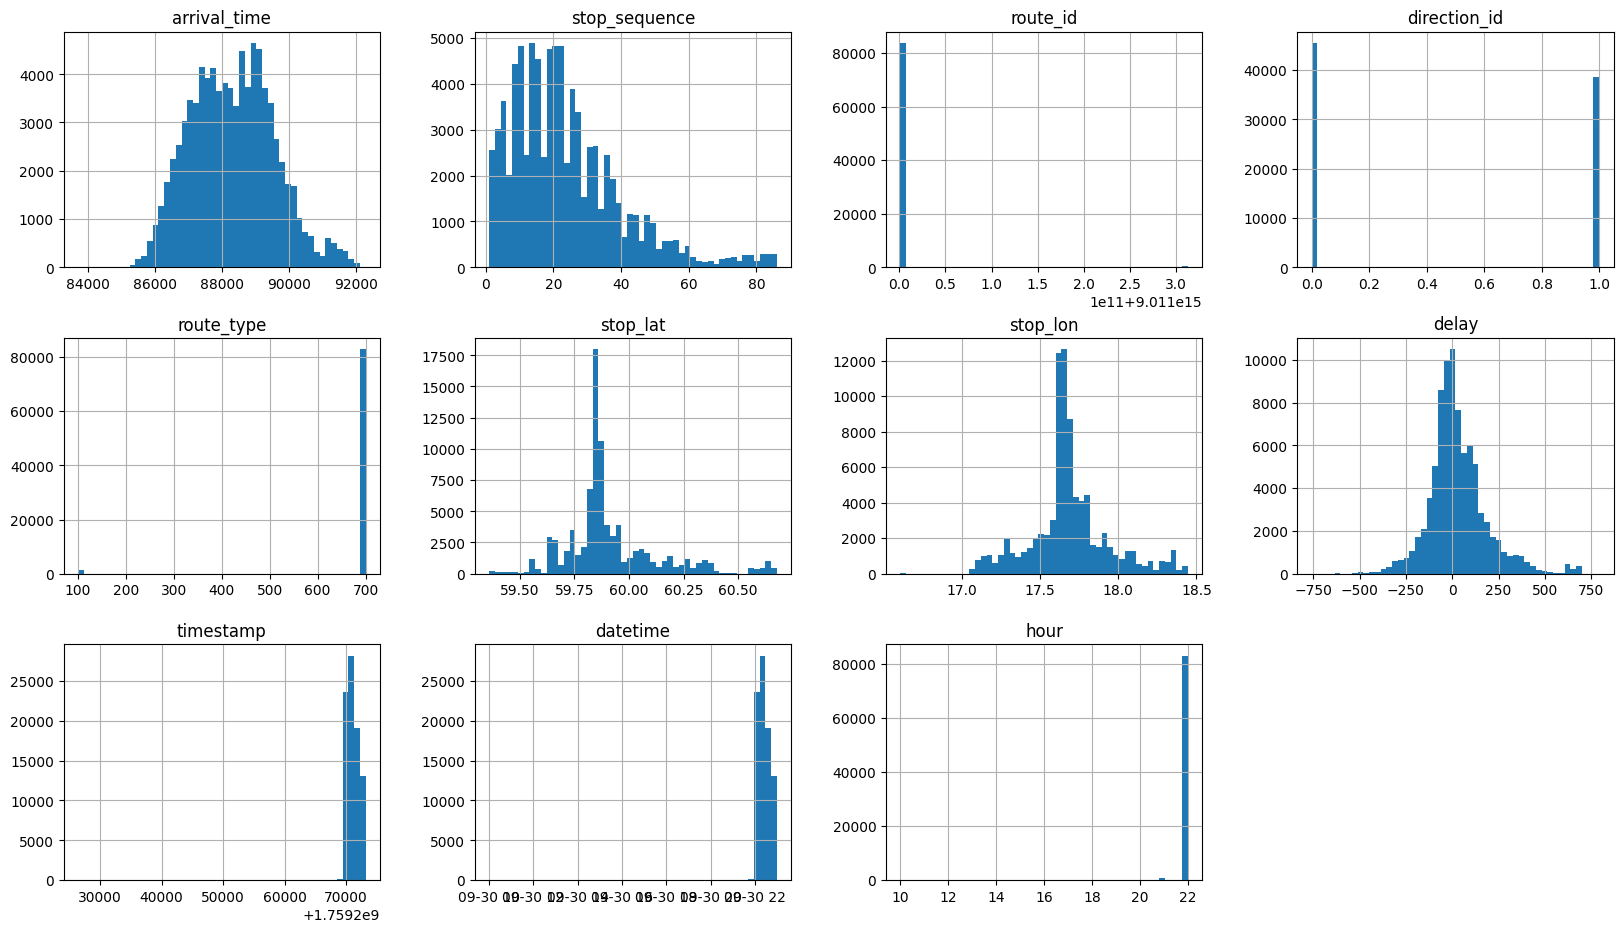

In [39]:
df.hist(bins=50, figsize=(20,15), layout=(4,4))

In [40]:
df['delay'].mean()

np.float64(30.091037713416085)

In [41]:
df['delay'].var()

24642.06467861449

In [42]:
df['delay'].std()

156.97791143538154

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: >

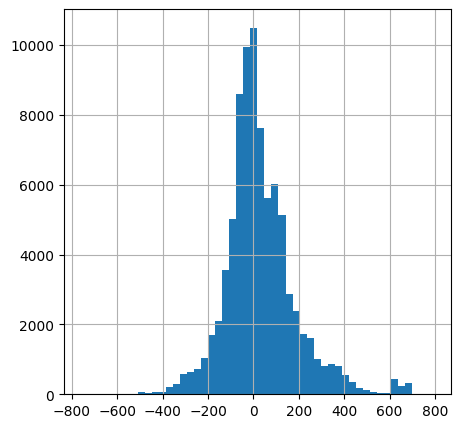

In [43]:
df['delay'].hist(bins=50, figsize=(5,5))

<Axes: xlabel='delay'>

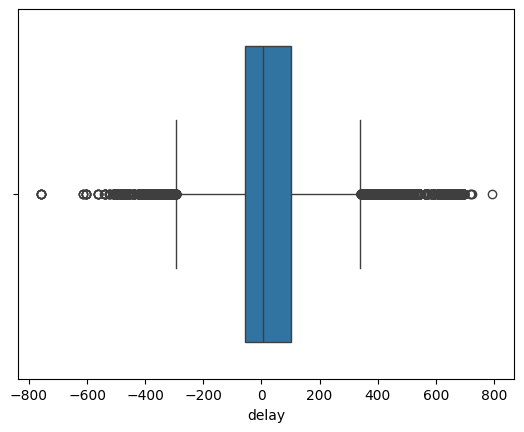

In [45]:
sns.boxplot(x=df['delay'])

#Finding the outliers/delay


In [46]:
q1= df['delay'].quantile(0.25)
q3= df['delay'].quantile(0.75)

In [47]:
l_bound = q1 - (1.5 * (q3-q1))
u_bound = q3 + (1.5 * (q3-q1))


In [48]:
outliers_lower = df[df['delay'] < l_bound]
outliers_upper = df[df['delay'] > u_bound]

In [49]:
print(f"Total Outliers: {len(outliers_lower) + len(outliers_upper)}")
print(f"Buses arriving way too early: {len(outliers_lower)}")
print(f"Buses arriving way too late: {len(outliers_upper)}")

Total Outliers: 5029
Buses arriving way too early: 1332
Buses arriving way too late: 3697


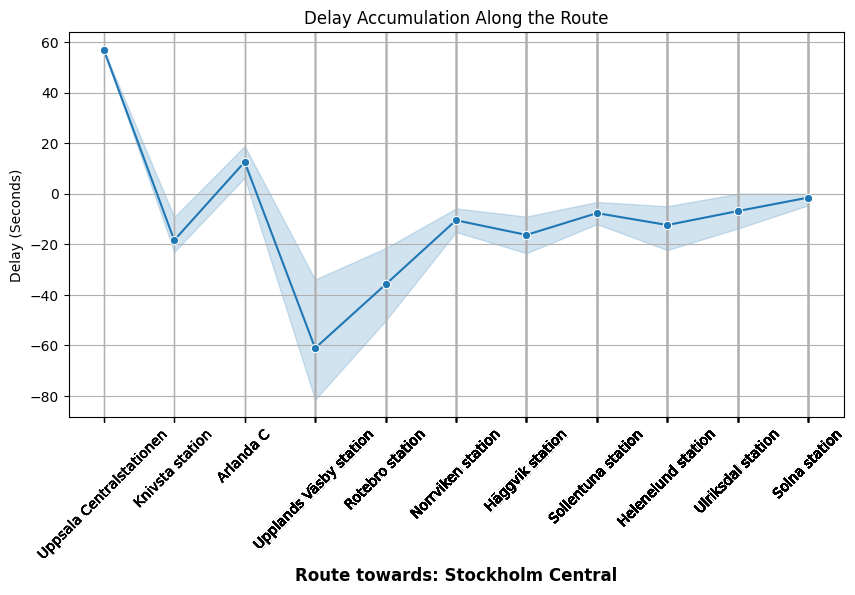

In [56]:
trip_id_mention= '33010000218710196'
trip_to_analyze = df[df['trip_id'] == trip_id_mention].sort_values('stop_sequence')
headsign = trip_to_analyze['stop_headsign'].iloc[0]

plt.figure(figsize=(10, 5))
sns.lineplot(data=trip_to_analyze, x='stop_sequence', y='delay', marker='o')

# 3. Labeling for clarity
plt.title("Delay Accumulation Along the Route")
plt.xticks(ticks= trip_to_analyze['stop_sequence'], labels= trip_to_analyze['stop_name'], rotation=45)
plt.xlabel(f"Route towards: {headsign}", fontsize=12, fontweight='bold')
plt.ylabel("Delay (Seconds)")
plt.grid(True)
plt.show()

#Delay without average

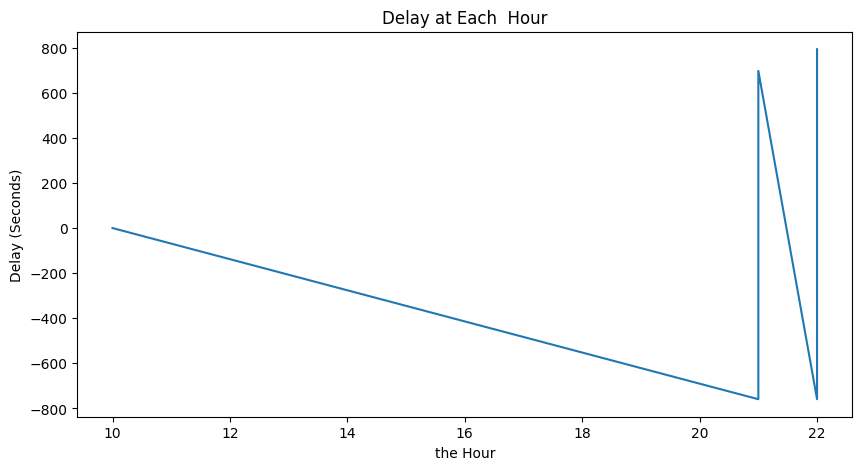

In [54]:
df['minute_of_hour'] = df['datetime'].dt.hour

plt.figure(figsize=(10, 5))
sns.lineplot(x= df['minute_of_hour'], y=df['delay'], data= df, estimator=None)
plt.title("Delay at Each  Hour")
plt.xlabel("the Hour")
plt.ylabel("Delay (Seconds)")
plt.show()

#Delay with Average

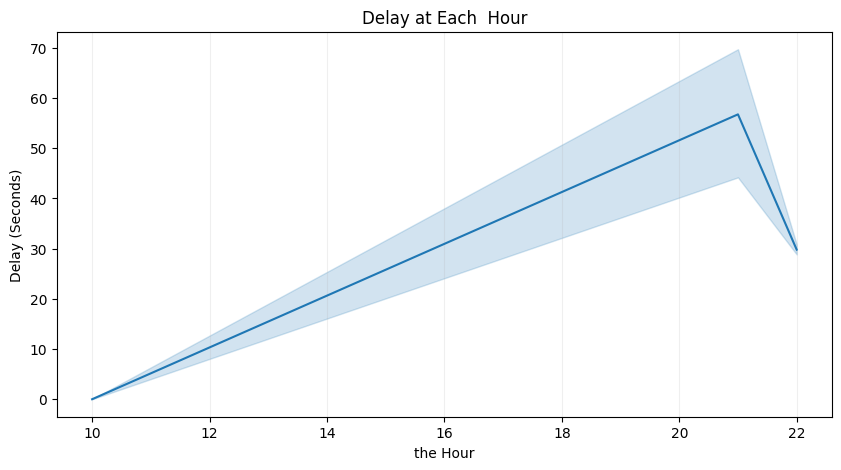

In [55]:
df['minute_of_hour'] = df['datetime'].dt.hour

plt.figure(figsize=(10, 5))
sns.lineplot(x= df['minute_of_hour'], y=df['delay'], data= df)
plt.title("Delay at Each  Hour")
plt.xlabel("the Hour")
plt.ylabel("Delay (Seconds)")
plt.grid(axis='x', alpha=0.2)
plt.show()

#Model Training and Prediction

#preparing the lag feature for the memory.

In [57]:
df= df.sort_values(['trip_id', 'stop_sequence'])

In [58]:
df['delay_lag1']= df.groupby('trip_id')['delay'].shift(1)
df['delay_lag2']= df.groupby('trip_id')['delay'].shift(2)

In [59]:
traindf= df.dropna(subset=['delay_lag1', 'delay_lag2'])

In [60]:
traindf.head(5)

,trip_id,stop_id,arrival_time,stop_sequence,stop_headsign,route_id,direction_id,route_type,stop_lat,stop_lon,stop_name,delay,timestamp,vehicle_id,datetime,hour,date,minute_of_hour,delay_lag1,delay_lag2
70218,33010000200952773,9022003700600011,85800,1,Storvreta,9011003011500000,0,700,59.857283,17.647516,Uppsala Centralstationen,22,1759269680,9031003000500652,2025-09-30 22:01:20,22,2025-09-30,22,22.0,22.0
70219,33010000200952773,9022003700600011,85800,1,Storvreta,9011003011500000,0,700,59.857283,17.647516,Uppsala Centralstationen,22,1759269612,9031003000500652,2025-09-30 22:00:12,22,2025-09-30,22,22.0,22.0
70220,33010000200952773,9022003700600011,85800,1,Storvreta,9011003011500000,0,700,59.857283,17.647516,Uppsala Centralstationen,22,1759269726,9031003000500652,2025-09-30 22:02:06,22,2025-09-30,22,22.0,22.0
70222,33010000200952773,9022003700600011,85800,1,Storvreta,9011003011500000,0,700,59.857283,17.647516,Uppsala Centralstationen,22,1759269660,9031003000500652,2025-09-30 22:01:00,22,2025-09-30,22,22.0,22.0
70223,33010000200952773,9022003700600011,85800,1,Storvreta,9011003011500000,0,700,59.857283,17.647516,Uppsala Centralstationen,22,1759269700,9031003000500652,2025-09-30 22:01:40,22,2025-09-30,22,22.0,22.0


In [71]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score

In [62]:
X= traindf[['delay_lag1', 'delay_lag2', 'hour', 'stop_sequence', 'stop_lat', 'stop_lon']]
y= traindf['delay']

In [63]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

In [65]:
rfmodel= RandomForestRegressor(n_estimators=100, criterion= 'squared_error', max_depth=5)
rfmodel.fit(X_train, y_train)

RandomForestRegressor(max_depth=5)

In [67]:
y_prediction = rfmodel.predict(X_test)

In [68]:
meanaerror= mean_absolute_error(y_test, y_prediction)
meanaerror

32.957464504552924

In [70]:
r2 = r2_score(y_test, y_prediction)
r2

0.8930053269086006

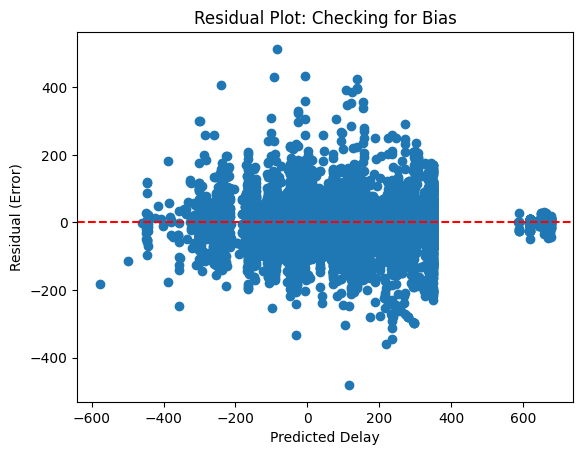

In [74]:
residuals = y_test - y_prediction

plt.scatter(y_prediction, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Delay")
plt.ylabel("Residual (Error)")
plt.title("Residual Plot: Checking for Bias")
plt.show()

In [75]:
from xgboost import XGBRegressor

In [76]:
xgbmodel= XGBRegressor(n_estimators= 100, max_depth=5, learning_rate=0.1, objective='reg:squarederror')
xgbmodel.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [77]:
y_predXgb= xgbmodel.predict(X_test)

In [82]:
#that mean on average it pred bus is 30.69 sec away from the truth value
maeXgb= mean_absolute_error(y_test, y_predXgb)
maeXgb

30.69593048095703

In [84]:
#r2 means, how well the model capture the variance of data
Xgbr2= r2_score(y_test, y_predXgb)
Xgbr2

0.9085149765014648